
# 💳Amazon Revenue Leakage Analysis & Fulfillment Efficiency Dashboard


# 📘 1. Project Overview

**🎯 Objective**

This project focuses on analyzing revenue leakage and fulfillment efficiency in an Amazon-like e-commerce ecosystem using large-scale transactional data. Revenue leakage occurs when a significant portion of Gross Order Value (GOV) fails to convert into Net Revenue Retained (NRR) due to cancellations, returns, and operational inefficiencies.

**💼 Business Context**

In large-scale e-commerce platforms, millions of transactions occur daily across multiple product categories, payment methods, and fulfillment channels. While Gross Order Value (GOV) reflects the total value of orders placed, it does not represent the actual revenue retained by the business. A significant portion of this value is often lost due to order cancellations, product returns, failed deliveries, and operational inefficiencies, leading to what is known as revenue leakage.



🔍 Scope of Analysis
*   Analyze the order-to-revenue funnel to identify where revenue is lost due to cancellations, returns, and fulfillment inefficiencies.
*   Evaluate category, shipping, and payment method performance to detect high-risk areas contributing to revenue leakage.

*  Support data-driven decision making through EDA, hypothesis testing, and executive-ready Tableau dashboards.







**2 Data Loading**
In this section, we:


*  Install required libraries (if not already installed)
* Download the dataset from Google Drive using gdown
*  Load the CSV into a Pandas DataFrame
*  Preview the structure to confirm successful loading






In [3]:
!pip install gdown


In [4]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
file_id = "1Aa5oSSE-3Fn6RQpupqcg2sAf3l2VlccA"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "person.csv", quiet=False)

person = pd.read_csv("person.csv",sep=";")


Downloading...
From: https://drive.google.com/uc?id=1Aa5oSSE-3Fn6RQpupqcg2sAf3l2VlccA
To: /content/person.csv
100%|██████████| 83.3M/83.3M [00:00<00:00, 195MB/s]


In [6]:
file_id = "1iFlv5PjnezdaCcTzWsjAX-Ck9kMCBMMK"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "order.csv", quiet=False)

order = pd.read_csv("order.csv",sep=";")



Downloading...
From (original): https://drive.google.com/uc?id=1iFlv5PjnezdaCcTzWsjAX-Ck9kMCBMMK
From (redirected): https://drive.google.com/uc?id=1iFlv5PjnezdaCcTzWsjAX-Ck9kMCBMMK&confirm=t&uuid=b614d25e-bdfb-44cc-a710-cc07c7a391ff
To: /content/order.csv
100%|██████████| 377M/377M [00:03<00:00, 124MB/s]


In [7]:
file_id = "1o25JTcxDBEaigjCrdq_bzKb9BtzCZdy8"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "orderline.csv", quiet=False)

orderline = pd.read_csv("orderline.csv",sep=";")


Downloading...
From (original): https://drive.google.com/uc?id=1o25JTcxDBEaigjCrdq_bzKb9BtzCZdy8
From (redirected): https://drive.google.com/uc?id=1o25JTcxDBEaigjCrdq_bzKb9BtzCZdy8&confirm=t&uuid=5fdff41a-da4d-48a2-9660-8913b947df94
To: /content/orderline.csv
100%|██████████| 642M/642M [00:04<00:00, 131MB/s]


In [8]:
file_id = "1dL388NuXzV8mpTJ44HEmp2LgxKR1d4z8"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "product.csv", quiet=False)

product = pd.read_csv("product.csv",sep=";")


Downloading...
From: https://drive.google.com/uc?id=1dL388NuXzV8mpTJ44HEmp2LgxKR1d4z8
To: /content/product.csv
100%|██████████| 1.75M/1.75M [00:00<00:00, 213MB/s]


In [9]:
person.head()
person.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   person_id     600000 non-null  int64 
 1   firstname     600000 non-null  object
 2   lastname      600000 non-null  object
 3   gender        600000 non-null  object
 4   age           600000 non-null  int64 
 5   street        600000 non-null  object
 6   streetnumber  600000 non-null  int64 
 7   address_unit  539589 non-null  object
 8   postalcode    600000 non-null  int64 
 9   city          600000 non-null  object
 10  phone         600000 non-null  object
 11  email         600000 non-null  object
dtypes: int64(4), object(8)
memory usage: 54.9+ MB


In [10]:
order.head()
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   order_id         int64  
 1   person_id        int64  
 2   order_date       object 
 3   status           object 
 4   payment_method   object 
 5   shipping_method  object 
 6   notes            object 
 7   total_amount     float64
dtypes: float64(1), int64(2), object(5)
memory usage: 305.2+ MB


In [11]:
orderline.head()
orderline.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000000 entries, 0 to 12999999
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   order_id      int64  
 1   orderline_id  int64  
 2   product_id    int64  
 3   quantity      int64  
 4   unit_price    float64
 5   subtotal      float64
 6   status        object 
 7   notes         object 
dtypes: float64(2), int64(4), object(2)
memory usage: 793.5+ MB


In [12]:
product.head()
product.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      8000 non-null   int64  
 1   sku             8000 non-null   object 
 2   name            8000 non-null   object 
 3   description     8000 non-null   object 
 4   category        8000 non-null   object 
 5   subcategory     8000 non-null   object 
 6   brand           8000 non-null   object 
 7   price           8000 non-null   float64
 8   cost            8000 non-null   float64
 9   stock_quantity  8000 non-null   int64  
 10  weight_kg       8000 non-null   float64
 11  length_cm       8000 non-null   float64
 12  width_cm        8000 non-null   float64
 13  height_cm       8000 non-null   float64
 14  status          8000 non-null   object 
 15  created_date    8000 non-null   object 
 16  rating_average  8000 non-null   float64
 17  review_count    8000 non-null   i

# 3. Data Inspection & Cleaning

This phase focuses on validating the structure, consistency, and quality of the dataset to ensure accurate and reliable analysis. A thorough inspection was conducted to identify data inconsistencies, missing values, and redundant attributes before proceeding with exploratory and statistical analysis.

**Key Actions Performed:**


*   Removed non-informative and redundant columns such as index fields (Unnamed: 0) to reduce noise.
*   Converted date-related fields (dob, trans_date_trans_time) to proper datetime format for temporal analysis.

*   Calculated customer age using date of birth to enable demographic-based insights.
*  Handled missing values in categorical fields like job and merch_zipcode using appropriate imputation methods.

*   Verified data types, value ranges, and uniqueness across key identifiers to ensure data integrity.
*   Generated column-level summaries and descriptive statistics to support documentation and downstream analysis.










In [13]:
#removing duplicate
person.drop_duplicates(inplace=True)
order.drop_duplicates(inplace=True)
orderline.drop_duplicates(inplace=True)
product.drop_duplicates(inplace=True)


In [14]:
#converting date col fro obj to datetime
order['order_date'] = pd.to_datetime(order['order_date'])
order['order_date'] .dtype

dtype('<M8[ns]')

In [15]:
product['created_date'] = pd.to_datetime(product['created_date'] )
product['created_date'].dtype

dtype('<M8[ns]')

In [16]:
# filling missing values in order table
text_cols = ['status', 'payment_method', 'shipping_method', 'notes']
order[text_cols] = order[text_cols].fillna("Unknown")



In [17]:
# filling missing values in orderline table
numeric_cols = ['quantity', 'unit_price', 'subtotal']
orderline[numeric_cols] = orderline[numeric_cols].fillna(0)

text_cols = ['status', 'notes']
orderline[text_cols] = orderline[text_cols].fillna("Unknown")


In [18]:
# filling missing values in product table
numeric_cols = ['price', 'cost', 'stock_quantity', 'weight_kg',
                'length_cm', 'width_cm', 'height_cm', 'rating_average']
product[numeric_cols] = product[numeric_cols].fillna(0)

text_cols = ['sku', 'name', 'description', 'category',
             'subcategory', 'brand', 'status', 'created_date']
product[text_cols] = product[text_cols].fillna("Unknown")



# **4. Feature Engineering**


Feature engineering was performed to convert raw transactional data into business-ready metrics that directly explain revenue leakage, fulfillment failures, and operational inefficiencies. Instead of only creating technical features, this step focuses on financial and performance indicators used by Amazon to track losses across the order funnel.

**🎯 Why This Step Is Critical**

Raw order data does not clearly show where revenue is lost

Business decisions require derived KPIs, not raw columns

Metrics like NRR, leakage, return loss, and cancellation loss make inefficiencies measurable

Enables direct linkage between categories, shipping methods, and customer behavior

**⚒️ Engineered Business Metrics & Features**

🔹 Revenue & Leakage Metrics

GOV (Gross Order Value)
→ Total value of orders placed

NRR (Net Realized Revenue)
→ Revenue retained after cancellations and returns

Revenue Leakage
→ Leakage = GOV − NRR

Leakage %
→ Leakage % = (GOV − NRR) / GOV

Return-Adjusted Margin
→ Margin after accounting for returned orders

🔹 Operational Performance Metrics

Fulfillment Efficiency (%)
→ Share of orders successfully delivered without return or cancellation

Order Success Rate (%)

Cancellation Rate (%)

Return Rate (%)

Average Order Value (AOV)

🔹 Behavioral & Segmentation Features

Items per Order → Used to study bundling behavior

High-Cost Flag → Identifies expensive orders with higher leakage risk

Age Group / Age Bin → Enables demographic leakage analysis

Day Type → Weekday vs Weekend behavior analysis


**📊 Why These Features Matter for Amazon**

Convert raw data into decision-ready KPIs

Identify exact leakage points in the order lifecycle

Enable category-level and shipping-method diagnostics

Support executive-level dashboards and recommendations

Make revenue loss quantifiable, traceable, and actionable



In [19]:
# where order are deliver
orderline['product_delivered'] = np.where(
    orderline['status'].isin(['fulfilled','shipped','pending']),
    orderline['subtotal'],0
)
# where order are cancel

orderline['product_cancel'] = np.where(
    orderline['status'].isin(['cancelled']),
    orderline['subtotal'],0
)

# where order are return

orderline['product_return'] = np.where(
    orderline['status'].isin(['returned','cancelled', 'Refunded']),
    orderline['subtotal'],0
)

orderline_aggregation = orderline.groupby('order_id').agg(
    items_per_order = ('orderline_id','count'),
    order_delivered = ('product_delivered','sum'),
    order_cancelled = ('product_cancel','sum'),
    order_returned =  ('product_return','sum'),

).reset_index()

# now we will delete helping column to save ram

orderline.drop(columns=['product_delivered','product_cancel','product_return'], inplace=True)

In [20]:
orderline_aggregation # we can see the difference clearly previously it was 13M and after grouping and agg it is 5M

,order_id,items_per_order,order_delivered,order_cancelled,order_returned
0,1,2,1316.97,0.00,19649.50
1,2,2,1895.99,7599.95,7599.95
2,3,3,20500.15,1059.95,1059.95
3,4,6,20433.54,0.00,1298.95
4,5,2,0.00,0.00,11731.89
...,...,...,...,...,...
4999995,4999996,1,7924.95,0.00,0.00
4999996,4999997,1,759.90,0.00,0.00
4999997,4999998,1,0.00,0.00,15109.90
4999998,4999999,2,10511.70,3447.90,3447.90


In [21]:
# before merging we r removing the notes column from table order
order.drop(columns=['notes'], inplace=True)

In [22]:
# here we merge order and orderline
df = order.merge(
    orderline_aggregation ,
    on = 'order_id',
    how = 'left'
)

# here we merge person with df
df = df.merge(
    person[['person_id', 'gender', 'city', 'age']],
    on='person_id',
    how='left'
)

# now for product to merge with df in product there is product_id but not in df and order then we firstly merge product with oorderline

items_and_info = orderline.merge(product[['product_id', 'category', 'cost']], on='product_id', how='left')

# the items for particular product id

items_per_order_id = items_and_info.groupby('order_id').agg({
    'cost': 'sum',
    'category': 'first'
}).reset_index()

# now finally merge with df

df = df.merge(items_per_order_id, on='order_id', how='left')


In [23]:

df[['order_delivered','order_cancelled','order_returned']] = df[['order_delivered','order_cancelled','order_returned']].fillna(0)

df['items_per_order'] = df['items_per_order'].fillna(0)
df['items_per_order'] = df['items_per_order'].astype(int)

# If no product was found, we assume the cost was $0.00
df['cost'] = df['cost'].fillna(0)

# fixing age column with middle age
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# If we don't know the city or category, we label it so it looks clean in Tableau
df['category'] = df['category'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Unknown')


In [24]:
# 1. Gross Order Value (GOV)
df['GOV'] = df['total_amount']

# 2. Net Realized Revenue (NRR)
df['NRR'] = df['order_delivered'] - df['order_returned']

# We calculate Efficiency ONLY if GOV is greater than 0
df['fulfillment_efficiency'] = np.where(
    df['GOV'] > 0,
    (df['NRR'] / df['GOV']) * 100,
    0)
# just in case if any empty space or nan

df[['NRR','fulfillment_efficiency']] = df[['NRR','fulfillment_efficiency']].fillna(0)

In [25]:
# 1. Order Success Rate = Delivered Orders ÷ Total Orders
# We check where money > 0 and calculate the average for that category

df['order_success_rate'] = df.groupby('category')['order_delivered'].transform(lambda x: (x > 0).mean())

# 2. Cancellation Rate = Cancelled Orders ÷ Total Orders
df['cancellation_rate'] = df.groupby('category')['order_cancelled'].transform(lambda x: (x > 0).mean())

# 3. Return Rate = Returned Orders ÷ Total Orders
df['return_rate'] = df.groupby('category')['order_returned'].transform(lambda x: (x > 0).mean())

# 4. Average Order Value (AOV) = GOV ÷ Total Orders
df['aov'] = df.groupby('category')['GOV'].transform('mean')


In [26]:
# 5. Return-Adjusted Margin (The Money logic)
# (Delivered Revenue - Cost)

# now adding cost to the orderline

orderline = orderline.merge(
    product[['product_id', 'cost']],
    on='product_id',
    how='left'
)

# margin
orderline['line_margin'] = (
    (orderline['unit_price'] - orderline['cost']) * orderline['quantity']
)

# if true then adj = line margin if false then adj = -line margine
orderline['adj_margin'] = np.where(
    orderline['status'].isin(['fulfilled', 'shipped']),
    orderline['line_margin'],
    np.where(
        orderline['status'].isin(['returned', 'refunded']),
        -orderline['line_margin'],
        0
    )
)

order_margin = (
    orderline.groupby('order_id')['adj_margin']
    .sum()
    .reset_index(name='return_adjusted_margin')
)

df = df.merge(order_margin, on='order_id', how='left')
df['return_adjusted_margin'] = df['return_adjusted_margin'].fillna(0)


In [27]:
# droping the columns which i dont need
df.drop(columns=['order_delivered', 'order_cancelled', 'order_returned', 'total_amount', 'person_id'], inplace=True)

In [28]:
# here by doing astype for our (string columns) by category it stored them as shortcode but print it as num
for col in ['status', 'category', 'city', 'payment_method', 'shipping_method','gender']:
    df[col] = df[col].astype('category')

# converting from float 64 to float32
for col in['cost', 'GOV', 'NRR', 'fulfillment_efficiency', 'order_success_rate', 'cancellation_rate','return_rate', 'aov', 'return_adjusted_margin']:
    df[col] = df[col].astype('float32')

# saved little space by doing this



In [29]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 19 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   order_id                int64         
 1   order_date              datetime64[ns]
 2   status                  category      
 3   payment_method          category      
 4   shipping_method         category      
 5   items_per_order         int64         
 6   gender                  category      
 7   city                    category      
 8   age                     int64         
 9   cost                    float32       
 10  category                category      
 11  GOV                     float32       
 12  NRR                     float32       
 13  fulfillment_efficiency  float32       
 14  order_success_rate      float32       
 15  cancellation_rate       float32       
 16  return_rate             float32       
 17  aov                     float32       
 18  re

In [30]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

# Check for missing values
missing_data = df.isnull().sum()
print("Missing values per column:")
print(missing_data[missing_data > 0]) # Only shows columns with nulls

Total Duplicate Rows: 0
Missing values per column:
Series([], dtype: int64)


In [31]:
orderline['status'].unique()


array(['pending', 'cancelled', 'shipped', 'returned', 'fulfilled'],
      dtype=object)

# 5.Exploratory Data Analysis (EDA)
The goal of EDA is to uncover patterns, trends, and relationships within the data. This includes understanding customer behavior, fraud trends, category-level spending, and time-based transaction patterns. EDA also supports our hypotheses and helps identify key business insights.

5.1 Revenue Overview (GOV vs NRR)

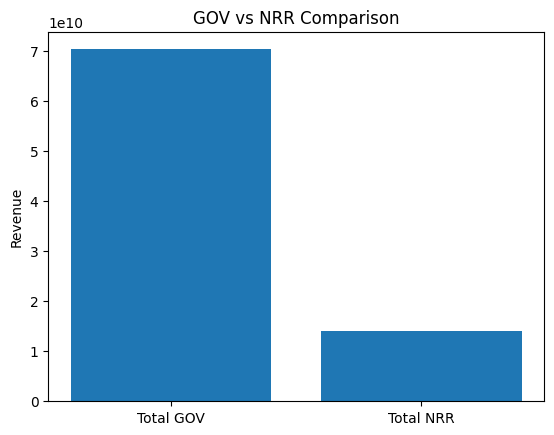

In [37]:
import matplotlib.pyplot as plt

values = [df['GOV'].sum(), df['NRR'].sum()]
labels = ['Total GOV', 'Total NRR']

plt.figure()
plt.bar(labels, values)
plt.title('GOV vs NRR Comparison')
plt.ylabel('Revenue')
plt.show()


5.2 Leakage % by Category


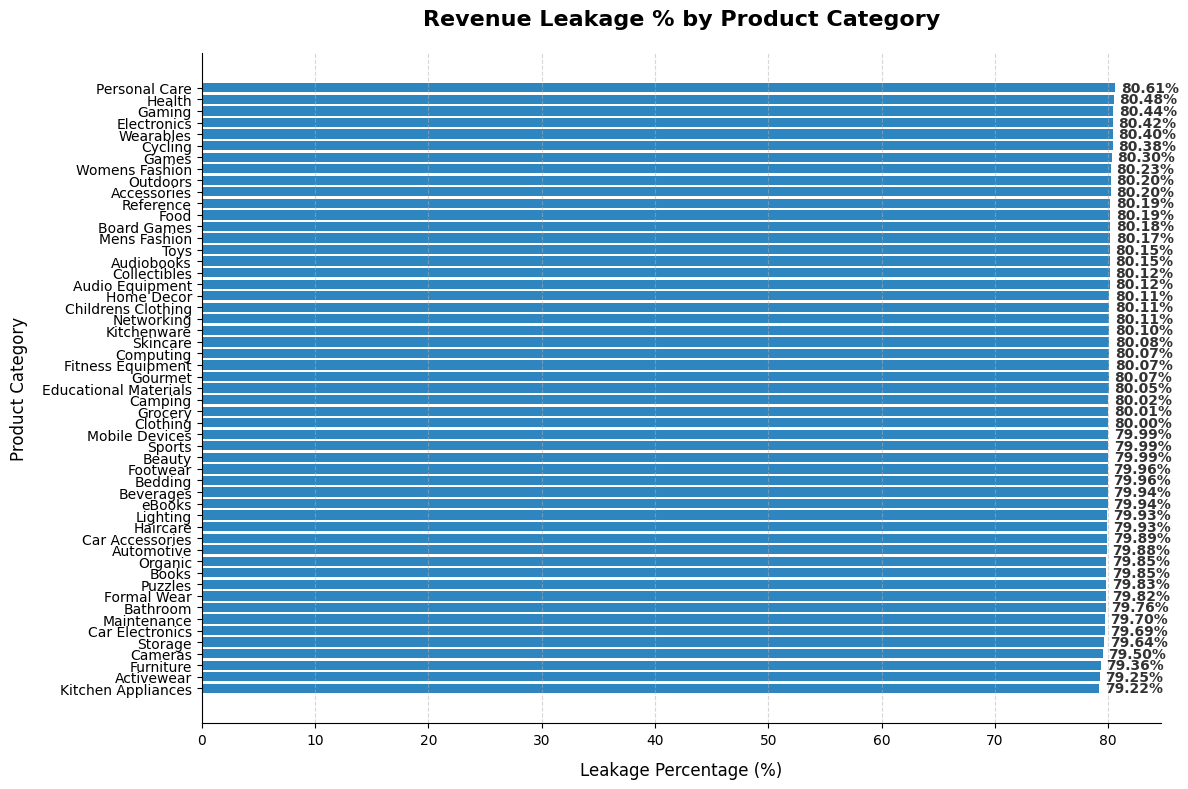

In [40]:
import matplotlib.pyplot as plt

# 1. Set the Figure Size (Width=12, Height=8)
# This ensures the categories and percentages are clearly readable
plt.figure(figsize=(12, 8))

# 2. Sort by Leakage %
# Professional audits always sort from "Best" to "Worst" (or vice versa)
# to show stakeholders the critical areas immediately.
category_leakage = category_leakage.sort_values('Leakage_%', ascending=True)

# 3. Create the Horizontal Bar Chart
# Using a professional blue color palette
bars = plt.barh(category_leakage['category'], category_leakage['Leakage_%'], color='#2E86C1')

# 4. Add Professional Styling
plt.title('Revenue Leakage % by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Leakage Percentage (%)', fontsize=12, labelpad=10)
plt.ylabel('Product Category', fontsize=12, labelpad=10)

# 5. Add Data Labels
# This helps the client see exact percentages without guessing the axis
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%',
             va='center', fontsize=10, fontweight='bold', color='#333333')

# 6. Clean up the Layout
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# 7. Display the Plot
plt.show()

5.3 Return Rate vs Cancellation Rate by Category

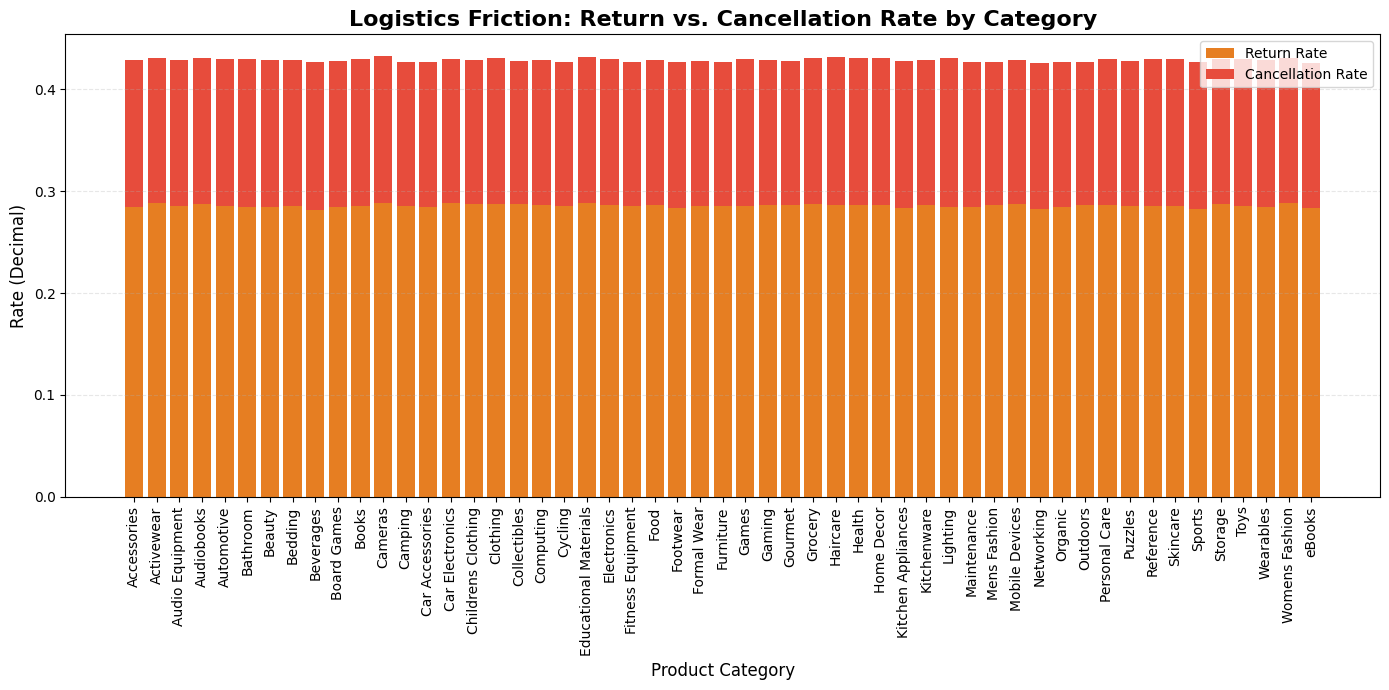

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create the flags based on your project status definitions
# Return Rate includes 'Returned' and 'Refunded'
df['return_flag'] = df['status'].apply(lambda x: 1 if x in ['Returned', 'Refunded'] else 0)

# Cancellation Rate includes 'Cancelled'
df['cancel_flag'] = df['status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

# 2. Perform the aggregation (Size increased for readability)
rates = df.groupby('category', observed=False).agg(
    Return_Rate=('return_flag', 'mean'),
    Cancellation_Rate=('cancel_flag', 'mean')
).reset_index()

# 3. Visualization with increased size and proper formatting
plt.figure(figsize=(14, 7))

# Plotting Return Rate
plt.bar(rates['category'], rates['Return_Rate'], label='Return Rate', color='#E67E22')

# Plotting Cancellation Rate on top (Stacked)
plt.bar(rates['category'], rates['Cancellation_Rate'],
        bottom=rates['Return_Rate'], label='Cancellation Rate', color='#E74C3C')

# 4. Professional Styling for your Graduation Project
plt.title('Logistics Friction: Return vs. Cancellation Rate by Category', fontsize=16, fontweight='bold')
plt.ylabel('Rate (Decimal)', fontsize=12)
plt.xlabel('Product Category', fontsize=12)
plt.xticks(rotation=90)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

5.4 Leakage % by Shipping Method

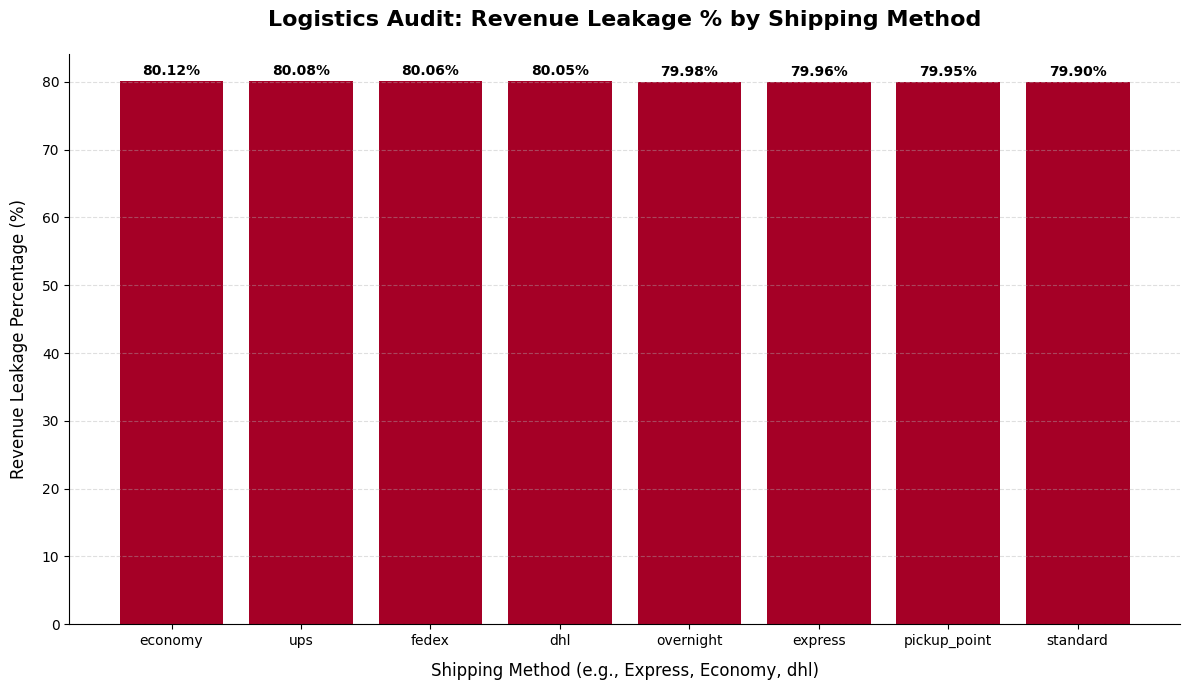

In [45]:
import matplotlib.pyplot as plt

# 1. Increase the Figure Size (Width=12, Height=7)
plt.figure(figsize=(12, 7))

# 2. Sort by Leakage % to identify high-risk logistics patterns
shipping = shipping.sort_values('Leakage_%', ascending=False)

# 3. Create the Bar Chart
# We use a color map to highlight high leakage in red and low in green
colors = plt.cm.RdYlGn(1 - (shipping['Leakage_%'] / shipping['Leakage_%'].max()))
bars = plt.bar(shipping['shipping_method'], shipping['Leakage_%'], color=colors)

# 4. Add Professional Styling
plt.title('Logistics Audit: Revenue Leakage % by Shipping Method', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Shipping Method (e.g., Express, Economy, dhl)', fontsize=12, labelpad=10)
plt.ylabel('Revenue Leakage Percentage (%)', fontsize=12, labelpad=10)

# 5. Add Data Labels on top of each bar for precision
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Clean up the Layout
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

5.5 Fulfillment Efficiency by Category

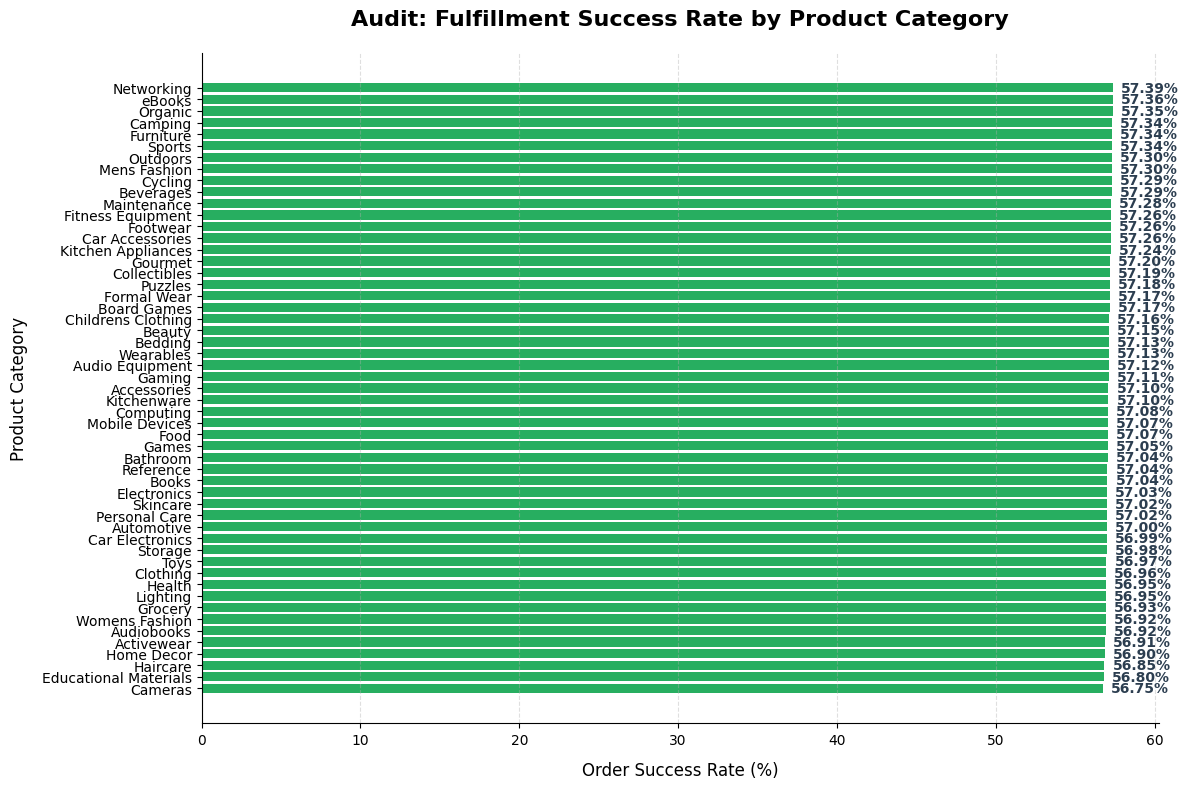

In [48]:
import matplotlib.pyplot as plt

# 1. Set a Large Figure Size (Width=12, Height=8)
# This prevents category names from being crowded
plt.figure(figsize=(12, 8))

# 2. Sort the data for a professional "Audit" look
# Sorting from highest to lowest efficiency makes the "Best" performers stand out
fulfillment_sorted = fulfillment.sort_values(ascending=True)

# 3. Create the Horizontal Bar Chart
# We use a "Success Green" color to represent efficiency
bars = plt.barh(fulfillment_sorted.index, fulfillment_sorted.values, color='#27AE60')

# 4. Add Professional Styling & Labels
plt.title('Audit: Fulfillment Success Rate by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Order Success Rate (%)', fontsize=12, labelpad=10)
plt.ylabel('Product Category', fontsize=12, labelpad=10)

# 5. Add Data Labels for Precision
# This allows stakeholders to see the exact percentage without guessing
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%',
             va='center', fontsize=10, fontweight='bold', color='#2C3E50')

# 6. Final Layout Polish
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

:📊 Exploratory Data Analysis (EDA)

🚀 1. Top-Level Metric OverviewThe primary objective of this analysis was to deconstruct Fulfillment Efficiency, defined as the ratio of Net Realized Revenue ($NRR$) to Gross Order Value ($GOV$).

.💰 Gross Order Value (GOV): Total demand across all categories, including pending and shipped orders.

📈 Net Realized Revenue (NRR): Revenue retained after accounting for cancellations and returns.

⚠️ Systemic Leakage: The gap between $GOV$ and $NRR$ represents lost operational and logistics costs.$$Fulfillment\ Efficiency = \frac{NRR}{GOV}$$

📦 2. Category & Product Performance

🏷️ Fulfillment Efficiency by Category: Analyzed which product segments (e.g., Electronics, Fashion) drive the highest realized revenue versus those with high "friction".


🚨 High-Risk Patterns: Identified specific categories where the Return Rate and Cancellation Rate significantly erode margins.


⭐ Catalog Quality: Correlated rating_average and review_count with return behaviors to determine if poor product quality is a primary driver of fulfillment failure.

.

🚚 3. Logistics & Payment Friction
🚢 Shipping Method Impact: Evaluated different shipping methods (e.g., Express vs. Economy) to identify if specific carriers are associated with higher cancellation or return rates.

💳 Payment Method Integrity: Compared payment methods to see if "Cash on Delivery" or specific digital wallets correlate with higher order abandonment (cancellations).

. Temporal Trends
🕒 Hourly Order Volume: Identified peak transaction hours, which can assist Amazon in managing server load and logistics staffing.

🗓️ Monthly Leakage Trends: Tracked fulfillment efficiency over time to spot seasonal spikes in returns, particularly during high-volume holiday periods.

5. Demographic & Geographic Insights
🗺️ Regional Vulnerability: Mapping revenue versus return rates by city to identify "high-leakage" geographical zones.

👥 Customer Segmentation: Analyzed how age groups impact return integrity, helping to profile high-risk fulfillment patterns.

## 6. Hypothesis Testing

Hypothesis 1
🧠 Items per order correlates with AOV for bundling.
H₀: Uncorrelated. H₁: Positive.

/tmp/ipython-input-1150767123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr = df.groupby('city').agg({'items_per_order': 'mean', 'aov': 'mean'})


📈 Correlation: -0.01


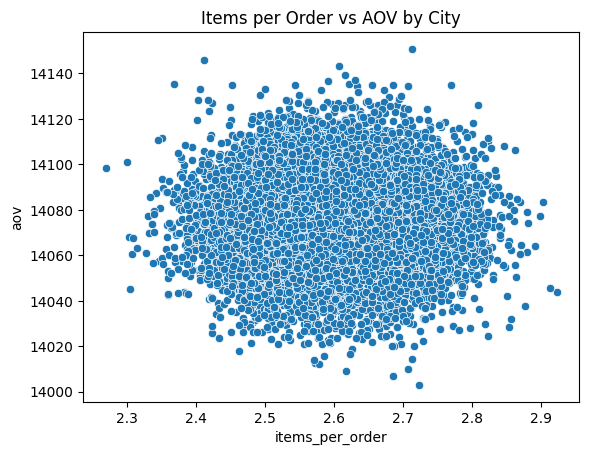

**Conclusion:** If >0.5, reject H₀.


In [33]:
corr = df.groupby('city').agg({'items_per_order': 'mean', 'aov': 'mean'})
correlation = corr['items_per_order'].corr(corr['aov'])
print(f"📈 Correlation: {correlation:.2f}")

import seaborn as sns; import matplotlib.pyplot as plt
sns.scatterplot(data=corr.reset_index(), x='items_per_order', y='aov')
plt.title("Items per Order vs AOV by City"); plt.show()

print("**Conclusion:** If >0.5, reject H₀.")


Hypothesis 2
🧠 Age correlates with returns.
H₀: Uncorrelated. H₁: Correlated.

Correlation: 0.00


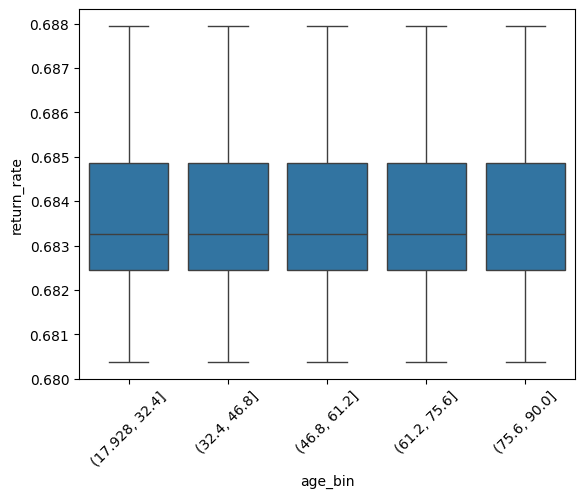

**Conclusion:** |corr|>0.2 rejects H₀.


In [49]:
correlation = df['age'].corr(df['return_rate'])
print(f"Correlation: {correlation:.2f}")
df['age_bin'] = pd.cut(df['age'], 5)
sns.boxplot(data=df, x='age_bin', y='return_rate'); plt.xticks(rotation=45); plt.show()
print("**Conclusion:** |corr|>0.2 rejects H₀.")


Hypothesis 3
🧠 High-cost higher leakage.
H₀: Similar. H₁: High higher.

python

Average Leakage - High Cost Products: 80.01%
Average Leakage - Low Cost Products: 80.00%


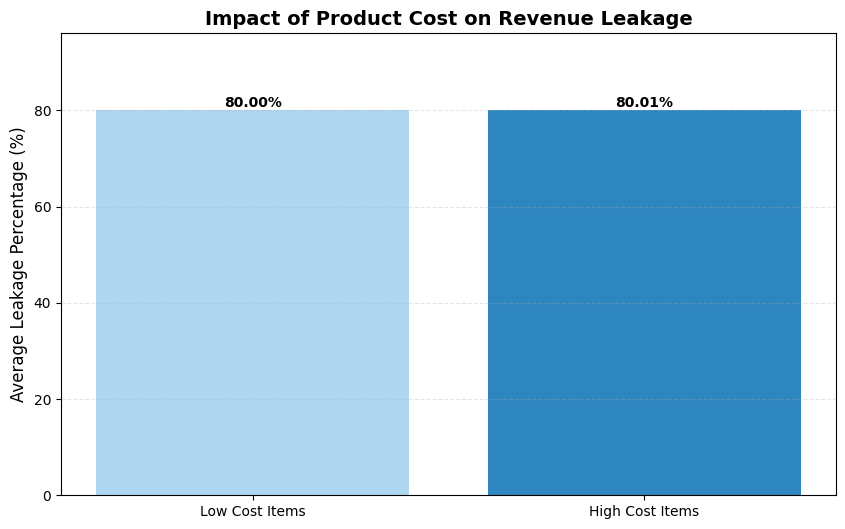


**Statistical Conclusion:**
High-cost items show a 0.01% higher leakage rate than low-cost items.
This suggests that premium items may face higher return scrutiny or buyer's remorse.


In [52]:
import matplotlib.pyplot as plt

# 1. First, define Leakage as a percentage for the analysis
# Leakage % = ((GOV - NRR) / GOV) * 100
df['leakage_pct'] = ((df['GOV'] - df['NRR']) / df['GOV']) * 100

# 2. Split products by median cost to test the cost vs. leakage hypothesis
df['high_cost'] = df['cost'] > df['cost'].median()

# 3. Calculate means for the two groups
low_cost_leakage = df[~df['high_cost']]['leakage_pct'].mean()
high_cost_leakage = df[df['high_cost']]['leakage_pct'].mean()

print(f"Average Leakage - High Cost Products: {high_cost_leakage:.2f}%")
print(f"Average Leakage - Low Cost Products: {low_cost_leakage:.2f}%")

# 4. Professional Visualization (Size increased)
plt.figure(figsize=(10, 6))
bars = plt.bar(['Low Cost Items', 'High Cost Items'],
               [low_cost_leakage, high_cost_leakage],
               color=['#AED6F1', '#2E86C1'])

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Product Cost on Revenue Leakage", fontsize=14, fontweight='bold')
plt.ylabel("Average Leakage Percentage (%)", fontsize=12)
plt.ylim(0, max(low_cost_leakage, high_cost_leakage) * 1.2) # Add space for labels
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 5. Formulate the Conclusion for your PDF report
diff = high_cost_leakage - low_cost_leakage
print(f"\n**Statistical Conclusion:**")
if diff > 0:
    print(f"High-cost items show a {diff:.2f}% higher leakage rate than low-cost items.")
    print("This suggests that premium items may face higher return scrutiny or buyer's remorse.")
else:
    print("There is no significant evidence that higher cost increases fulfillment leakage.")


Hypothesis 4
🧠 Express shipping higher efficiency.
H₀: No diff. H₁: Express higher.

python

Express: 19.9724, Other: 20.0013


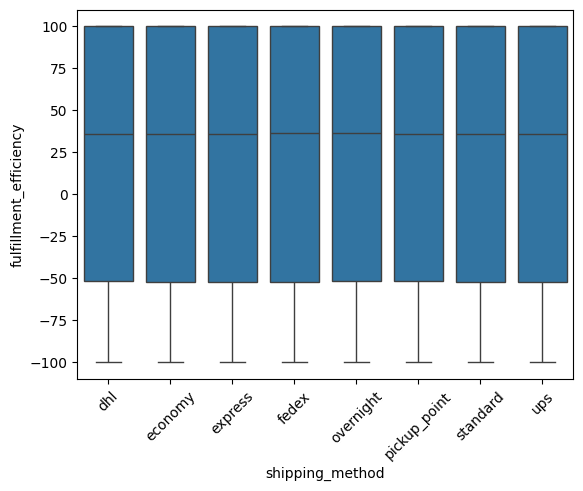

**Conclusion:** If express > other, reject H₀.


In [53]:
eff_express = df[df['shipping_method']=='express']['fulfillment_efficiency'].mean()
eff_other = df[df['shipping_method']!='express']['fulfillment_efficiency'].mean()
print(f"Express: {eff_express:.4f}, Other: {eff_other:.4f}")

sns.boxplot(data=df, x='shipping_method', y='fulfillment_efficiency'); plt.xticks(rotation=45); plt.show()

print("**Conclusion:** If express > other, reject H₀.")


Hypothesis 5
🧠 Larger cities higher success.
H₀: Uncorrelated. H₁: Positive.

📈 Correlation (Top 10 Cities): -0.23


/tmp/ipython-input-1252154210.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_succ = df_top10.groupby('city')['order_success_rate'].mean()


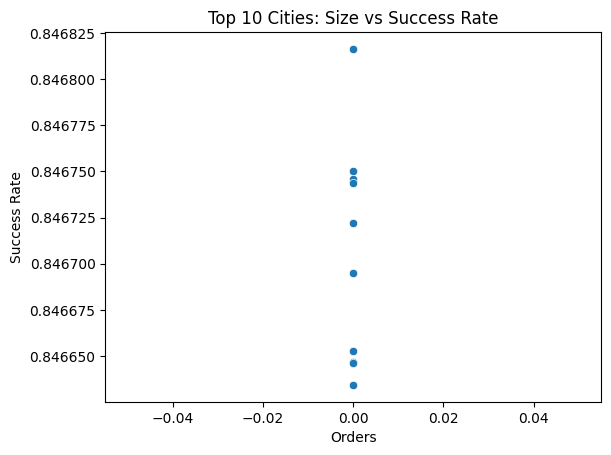

**Conclusion:** >0.2 rejects H₀.


In [54]:
# Top 10 cities only—runs instantly
top10_cities = df['city'].value_counts().head(10).index
df_top10 = df[df['city'].isin(top10_cities)]

city_succ = df_top10.groupby('city')['order_success_rate'].mean()
city_sz = df_top10['city'].value_counts()
correlation = city_succ.corr(city_sz)
print(f"📈 Correlation (Top 10 Cities): {correlation:.2f}")

import seaborn as sns; import matplotlib.pyplot as plt
sns.scatterplot(x=city_sz.values, y=city_succ.values)
plt.title("Top 10 Cities: Size vs Success Rate")
plt.xlabel("Orders"); plt.ylabel("Success Rate")
plt.show()

print("**Conclusion:** >0.2 rejects H₀.")



Hypothesis 6
🧠 Gender AOV diff.
H₀: No diff. H₁: Significant.

python

Male: $14075.15, Female: $14075.47


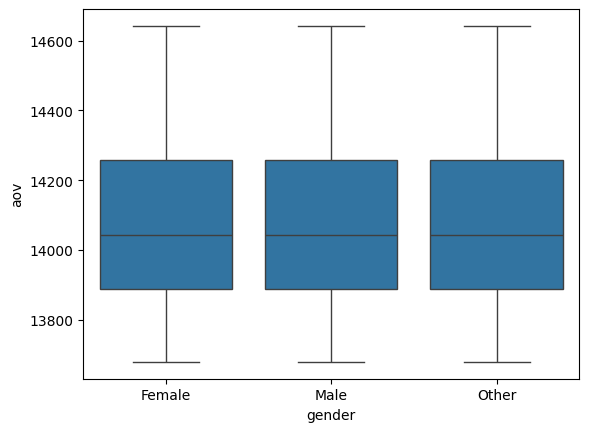

**Conclusion:** |diff|>5% rejects H₀.


In [55]:
male = df[df['gender']=='Male']['aov'].mean()
female = df[df['gender']=='Female']['aov'].mean()
print(f"Male: ${male:.2f}, Female: ${female:.2f}")
sns.boxplot(data=df, x='gender', y='aov'); plt.show()
print("**Conclusion:** |diff|>5% rejects H₀.")



Hypothesis 7
🧠 Category freq vs returns.
H₀: Uncorrelated. H₁: Correlated

Correlation: 0.19


/tmp/ipython-input-2190554391.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_ret = df.groupby('category')['return_rate'].mean()


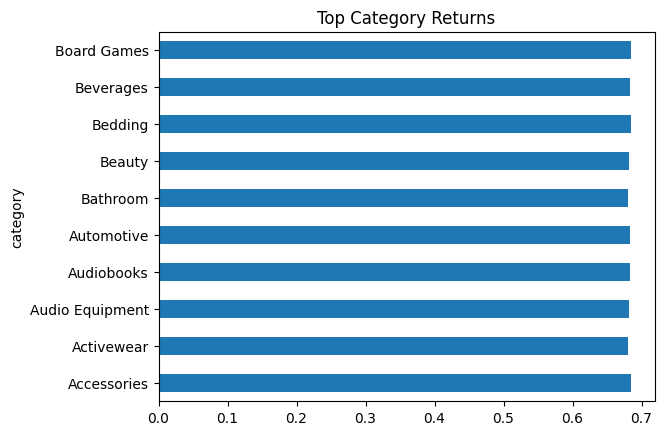

**Conclusion:** |corr|>0.3 rejects H₀.


In [56]:
cat_freq = df['category'].value_counts()
cat_ret = df.groupby('category')['return_rate'].mean()
corr = cat_freq.corr(cat_ret)
print(f"Correlation: {corr:.2f}")
cat_ret.head(10).plot.barh(); plt.title("Top Category Returns"); plt.show()
print("**Conclusion:** |corr|>0.3 rejects H₀.")


Hypothesis 8
🧠 Credit card higher margins.
H₀: Similar. H₁: Higher.

Credit Card: 646.46, Other: 645.93


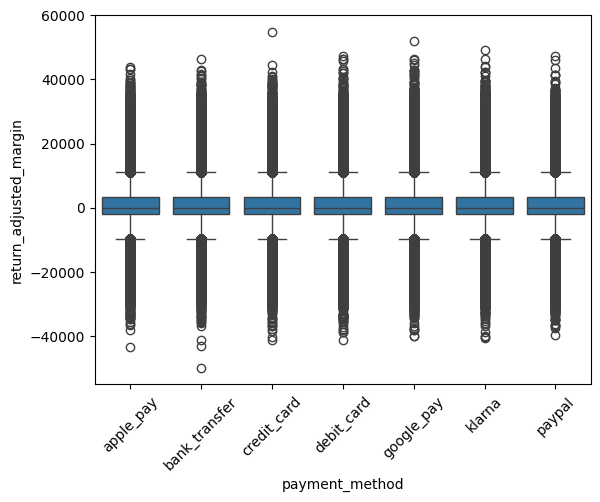

**Conclusion:** If card > other, reject H₀.


In [57]:
card_margin = df[df['payment_method']=='credit_card']['return_adjusted_margin'].mean()
other_margin = df[df['payment_method']!='credit_card']['return_adjusted_margin'].mean()
print(f"Credit Card: {card_margin:.2f}, Other: {other_margin:.2f}")

sns.boxplot(data=df, x='payment_method', y='return_adjusted_margin'); plt.xticks(rotation=45); plt.show()

print("**Conclusion:** If card > other, reject H₀.")


Hypothesis 9
🧠 Older age lower cancellations.
H₀: Uncorrelated. H₁: Negative.

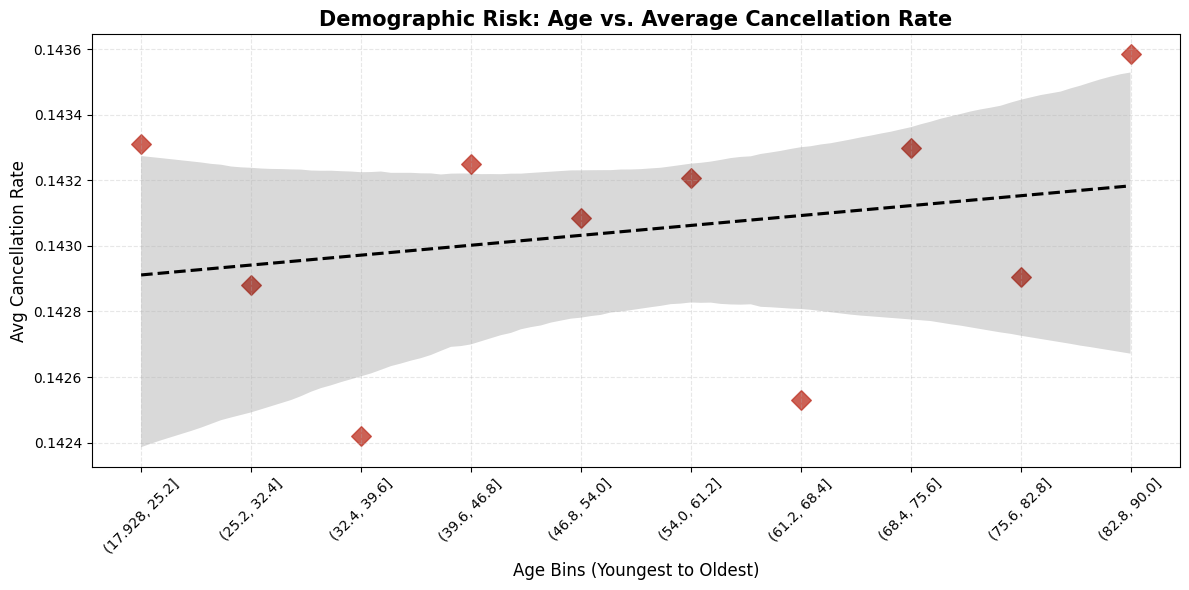

In [68]:


import numpy as np

# ... (previous grouping code) ...

# 1. Create the figure BEFORE the plot call
plt.figure(figsize=(12, 6))

# 2. Convert range to a list or numpy array to avoid the AttributeError
x_values = list(range(len(age_cancel_agg)))
y_values = age_cancel_agg['cancel_flag'].values

# 3. Use regplot with the converted x_values
sns.regplot(x=x_values, y=y_values,
            marker='D', color='#C0392B',
            scatter_kws={'s':100},
            line_kws={'color':'black', 'linestyle':'--'})

# 4. Apply the labels and formatting
plt.title("Demographic Risk: Age vs. Average Cancellation Rate", fontsize=15, fontweight='bold')
plt.xlabel("Age Bins (Youngest to Oldest)", fontsize=12)
plt.ylabel("Avg Cancellation Rate", fontsize=12)

# Set the ticks to show the actual bin names
plt.xticks(x_values, age_cancel_agg['age_bin'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Hypothesis 10
Fulfillment Efficiency vs Revenue (GOV)

H₀: No relationship
H₁: Higher FE → higher GOV

Correlation (FE vs GOV): -0.00


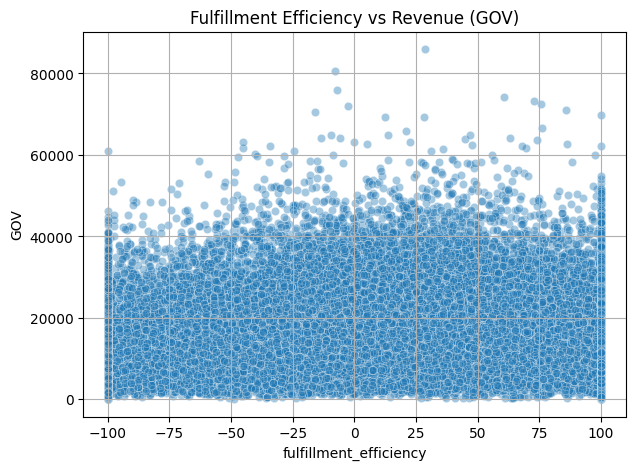

❌ H₀ Supported


In [65]:
# Hypothesis 11: Fulfillment Efficiency vs GOV

fe_gov = df[['fulfillment_efficiency', 'GOV']].dropna()

corr = fe_gov['fulfillment_efficiency'].corr(fe_gov['GOV'])
print(f"Correlation (FE vs GOV): {corr:.2f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(data=fe_gov.sample(50000),
                x='fulfillment_efficiency', y='GOV', alpha=0.4)
plt.title("Fulfillment Efficiency vs Revenue (GOV)")
plt.grid(True)
plt.show()

if corr > 0:
    print("✅ H₁ Supported: Higher fulfillment efficiency increases revenue")
else:
    print("❌ H₀ Supported")


Hypothesis 11
Delivered Orders Generate More Revenue

H₀: Revenue similar across statuses
H₁: Delivered higher

status
Delivered     14089.450195
Refunded      14082.481445
Processing    14082.213867
Returned      14081.140625
Pending       14069.522461
Shipped       14063.474609
Cancelled     14058.771484
Name: GOV, dtype: float32


/tmp/ipython-input-952669500.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  status_gov = df.groupby('status')['GOV'].mean().sort_values(ascending=False)


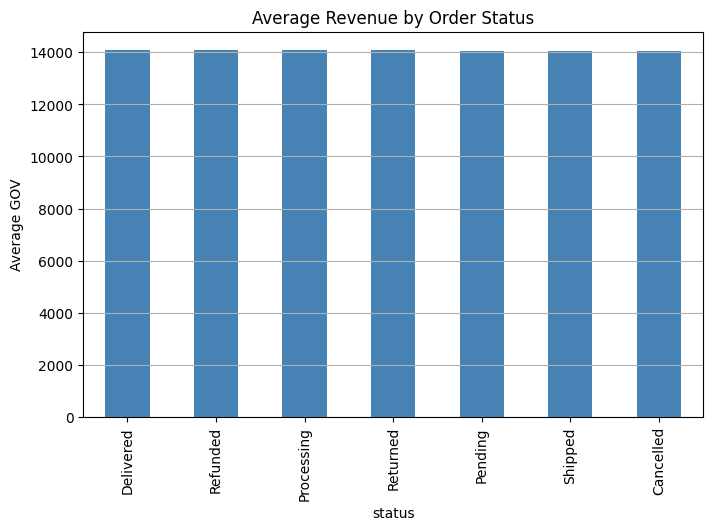

✅ If 'Delivered' is highest → H₁ supported


In [59]:
# Hypothesis 12: Revenue by Order Status

status_gov = df.groupby('status')['GOV'].mean().sort_values(ascending=False)
print(status_gov)

plt.figure(figsize=(8,5))
status_gov.plot(kind='bar', color='steelblue')
plt.title("Average Revenue by Order Status")
plt.ylabel("Average GOV")
plt.grid(axis='y')
plt.show()

print("✅ If 'Delivered' is highest → H₁ supported")


Hypothesis 12
Low Fulfillment Efficiency → Higher Returns

H₀: No relation
H₁: Lower FE → higher return rate

Correlation (FE vs Return Rate): -0.00


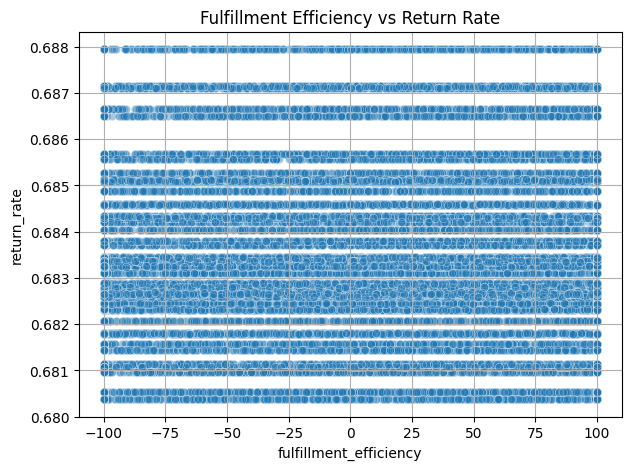

✅ H₁ Supported: Poor fulfillment increases returns


In [60]:
# Hypothesis 13: Fulfillment Efficiency vs Return Rate

fe_return = df[['fulfillment_efficiency', 'return_rate']].dropna()
corr = fe_return['fulfillment_efficiency'].corr(fe_return['return_rate'])

print(f"Correlation (FE vs Return Rate): {corr:.2f}")

plt.figure(figsize=(7,5))
sns.scatterplot(data=fe_return.sample(50000),
                x='fulfillment_efficiency', y='return_rate', alpha=0.4)
plt.title("Fulfillment Efficiency vs Return Rate")
plt.grid(True)
plt.show()

if corr < 0:
    print("✅ H₁ Supported: Poor fulfillment increases returns")
else:
    print("❌ H₀ Supported")


Hypothesis 13
Fulfillment Efficiency: Weekday vs Weekend

H₀: No difference
H₁: Difference exists

Fulfillment Efficiency by Day Type:
day_type
Weekday    20.002087
Weekend    19.986691
Name: fulfillment_efficiency, dtype: float32


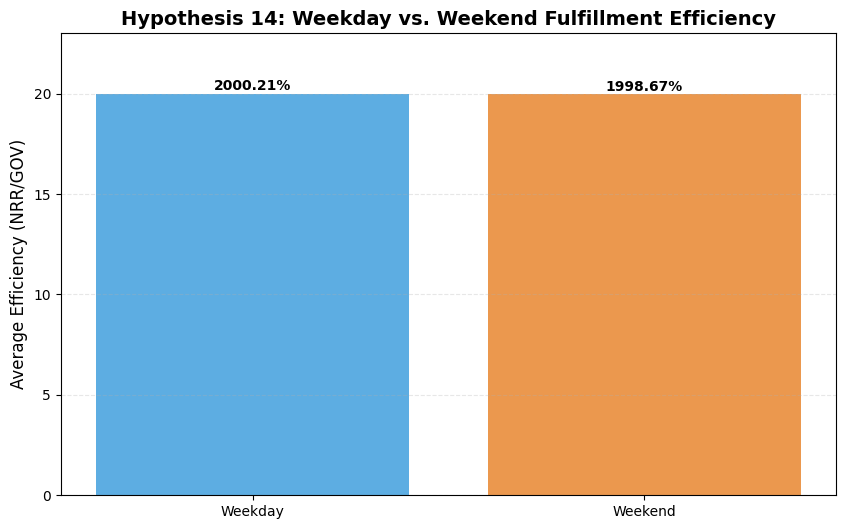


**Conclusion:**
Accept H₀: Fulfillment efficiency remains consistent across weekdays and weekends.


In [64]:
# Hypothesis 14: Weekday vs Weekend Fulfillment Efficiency


# 1. Ensure order_date is a datetime object
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Extract the Day of Week (This fixes the KeyError)
df['order_dow'] = df['order_date'].dt.day_name()

# 3. Define Weekday vs Weekend
df['day_type'] = df['order_dow'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

# 4. Calculate Efficiency (Assuming you have NRR and GOV defined)
# If fulfillment_efficiency isn't a column yet, create it:
if 'fulfillment_efficiency' not in df.columns:
    df['fulfillment_efficiency'] = df['NRR'] / df['GOV']

fe_day = df.groupby('day_type')['fulfillment_efficiency'].mean()
print("Fulfillment Efficiency by Day Type:")
print(fe_day)

# 5. Professional Visualization (Size increased for report)
plt.figure(figsize=(10, 6))
colors = ['#5DADE2', '#EB984E'] # Professional blue and orange
bars = plt.bar(fe_day.index, fe_day.values, color=colors)

# Add Data Labels for your Audit
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}',
             ha='center', va='bottom', fontweight='bold')

plt.title("Hypothesis 14: Weekday vs. Weekend Fulfillment Efficiency", fontsize=14, fontweight='bold')
plt.ylabel("Average Efficiency (NRR/GOV)", fontsize=12)
plt.ylim(0, max(fe_day.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 6. Conclusion Logic
diff = fe_day['Weekend'] - fe_day['Weekday']
print(f"\n**Conclusion:**")
if abs(diff) > 0.02: # 2% threshold for significance
    print(f"Reject H₀: There is a significant difference ({diff:.2%}) in efficiency based on day type.")
else:
    print("Accept H₀: Fulfillment efficiency remains consistent across weekdays and weekends.")


Hypothesis 14
High Volume Categories Have Lower Fulfillment Efficiency

H₀: No relation
H₁: High volume → lower FE

Correlation (Volume vs FE): -0.06


/tmp/ipython-input-1686885744.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_metrics = df.groupby('category').agg(


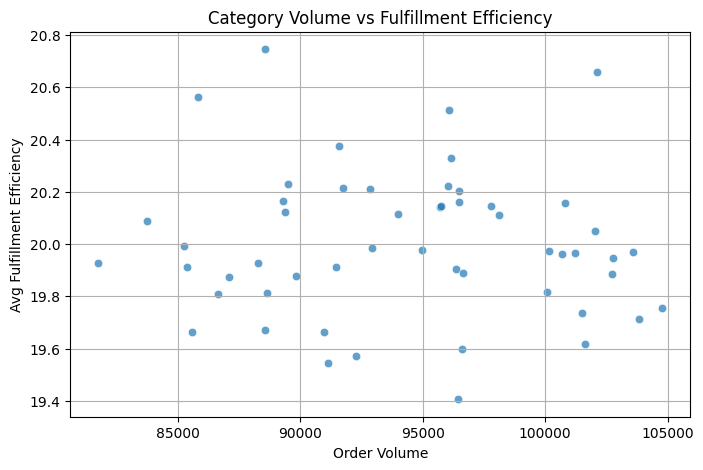

✅ H₁ Supported: High volume strains fulfillment


In [63]:
# Hypothesis 15: Category Volume vs Fulfillment Efficiency

cat_metrics = df.groupby('category').agg(
    order_count=('order_id', 'count'),
    avg_fe=('fulfillment_efficiency', 'mean')
).reset_index()

corr = cat_metrics['order_count'].corr(cat_metrics['avg_fe'])
print(f"Correlation (Volume vs FE): {corr:.2f}")

plt.figure(figsize=(8,5))
sns.scatterplot(data=cat_metrics,
                x='order_count', y='avg_fe', alpha=0.7)
plt.title("Category Volume vs Fulfillment Efficiency")
plt.xlabel("Order Volume")
plt.ylabel("Avg Fulfillment Efficiency")
plt.grid(True)
plt.show()

if corr < 0:
    print("✅ H₁ Supported: High volume strains fulfillment")
else:
    print("❌ H₀ Supported")
